### Emotion-Aware Sentiment-to-Speech System
- Multi-class emotion classification for expressive robotic voices
- Adds prosody controls: rate, volume, and pitch (with safe fallback)
- Supports long-form paragraph input via sentence chunking

In [ ]:
import os
import sys
import re
import asyncio
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline
import pyttsx3
from IPython.display import Audio, display

# Optional Edge TTS (free, cloud voice) for more natural speech
try:
    import edge_tts
    EDGE_TTS_AVAILABLE = True
except Exception:
    EDGE_TTS_AVAILABLE = False

# Sentence tokenizer with automatic fallback (no manual flags)
try:
    import nltk
    from nltk.tokenize import sent_tokenize as _nltk_sent_tokenize

    def sentence_tokenize(text):
        return [s.strip() for s in _nltk_sent_tokenize(text) if s.strip()]

except Exception:
    def sentence_tokenize(text):
        return [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]

# Load a multi-class emotion model (replaces binary sentiment SST-2)
emotion_analyzer = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    truncation=True,
    # top_k=None returns all classes for richer analysis.
    # truncation=True safely handles long single sequences at model level.
    )
print("Emotion model loaded successfully!")
print(f"Edge TTS available: {EDGE_TTS_AVAILABLE}")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Emotion model loaded successfully!
Edge TTS available: True


In [51]:
def split_sentences(text):
    """Split text into clean sentences using tokenizer fallback chain."""
    cleaned = text.strip()
    if not cleaned:
        return []
    return sentence_tokenize(cleaned)


def analyze_emotion(text):
    """Analyze emotion and return top label, confidence, and full score map."""
    raw = emotion_analyzer(text)[0]
    # raw is a list of {'label': ..., 'score': ...} entries when top_k=None
    best = max(raw, key=lambda x: x["score"] )
    score_map = {item["label"].lower(): float(item["score"]) for item in raw}
    return {
        "text": text,
        "label": best["label"].lower(),
        "score": float(best["score"]),
        "all_scores": score_map
    }


# Quick test
test_text = "I absolutely love this amazing product! It makes me so happy!"
emotion_result = analyze_emotion(test_text)
print(f"Input: {emotion_result['text']}")
print(f"Emotion: {emotion_result['label']} (confidence: {emotion_result['score']:.2%})")

Input: I absolutely love this amazing product! It makes me so happy!
Emotion: joy (confidence: 97.65%)


In [39]:
def emotion_to_voice(emotion_label, confidence):
    """Map multi-class emotion to expressive TTS parameters with stronger contrast."""
    base_rate = 150
    base_volume = 0.75
    base_pitch = 50  # 0-100 scale (engine support varies by platform)

    mapping = {
        "joy": {"rate_mod": 70, "vol_mod": 0.30, "pitch_mod": 24, "pause_ms": 90},
        "anger": {"rate_mod": 95, "vol_mod": 0.40, "pitch_mod": 32, "pause_ms": 60},
        "sadness": {"rate_mod": -75, "vol_mod": -0.50, "pitch_mod": -26, "pause_ms": 320},
        "fear": {"rate_mod": 45, "vol_mod": -0.30, "pitch_mod": 16, "pause_ms": 220},
        "surprise": {"rate_mod": 80, "vol_mod": 0.32, "pitch_mod": 30, "pause_ms": 70},
        "neutral": {"rate_mod": 0, "vol_mod": 0.00, "pitch_mod": 0, "pause_ms": 150},
        "disgust": {"rate_mod": -35, "vol_mod": -0.25, "pitch_mod": -14, "pause_ms": 200},
        "love": {"rate_mod": 50, "vol_mod": 0.22, "pitch_mod": 18, "pause_ms": 110}
    }

    mods = mapping.get(emotion_label.lower(), mapping["neutral"] )

    # Keep a minimum modulation even for mid-confidence predictions.
    intensity = 0.35 + (0.65 * float(confidence))
    rate = int(np.clip(base_rate + (intensity * mods["rate_mod"]), 80, 260))
    volume = float(np.clip(base_volume + (intensity * mods["vol_mod"]), 0.05, 1.0))
    pitch = int(np.clip(base_pitch + (intensity * mods["pitch_mod"]), 10, 95))
    pause_ms = int(np.clip(mods["pause_ms"], 50, 450))
    return rate, volume, pitch, pause_ms


def safe_set_pitch(engine, pitch):
    """Attempt pitch control; return False when backend does not support it."""
    try:
        engine.setProperty("pitch", int(pitch))
        return True
    except Exception:
        return False


# Test voice parameter mapping
for lbl, conf in [("joy", 0.93), ("anger", 0.89), ("sadness", 0.91), ("neutral", 0.75)]:
    r, v, p, pause = emotion_to_voice(lbl, conf)
    print(f"{lbl:8s} -> rate={r}, volume={v:.2f}, pitch={p}, pause_ms={pause}")

joy      -> rate=216, volume=1.00, pitch=72, pause_ms=90
anger    -> rate=238, volume=1.00, pitch=79, pause_ms=60
sadness  -> rate=80, volume=0.28, pitch=25, pause_ms=320
neutral  -> rate=150, volume=0.75, pitch=50, pause_ms=150


In [40]:
def emotion_to_edge_voice(emotion_label):
    """Pick natural Edge voice style by emotion."""
    voice_map = {
        "joy": "en-US-JennyNeural",
        "anger": "en-US-GuyNeural",
        "sadness": "en-GB-SoniaNeural",
        "fear": "en-US-AriaNeural",
        "surprise": "en-US-JennyNeural",
        "neutral": "en-US-AriaNeural",
        "disgust": "en-US-GuyNeural",
        "love": "en-US-JennyNeural"
    }
    return voice_map.get(emotion_label.lower(), "en-US-AriaNeural")


def prosody_to_edge_params(rate, volume, pitch):
    """Convert numeric prosody into Edge-compatible string values with stronger contrast."""
    # Edge expects strings like '+10%', '-5%', '+2Hz'
    rate_pct = int(np.clip((rate - 150) * 0.9, -80, 80))
    vol_pct = int(np.clip((volume - 0.75) * 140, -70, 70))
    pitch_hz = int(np.clip((pitch - 50) * 2.2, -45, 45))
    return f"{rate_pct:+d}%", f"{vol_pct:+d}%", f"{pitch_hz:+d}Hz"


async def generate_edge_audio(text, emotion_label, confidence, audio_file="edge_preview.mp3"):
    """Generate more natural voice audio using free Edge TTS when available."""
    if not EDGE_TTS_AVAILABLE:
        raise RuntimeError("edge-tts is not installed. Run: pip install edge-tts")

    rate, volume, pitch, _ = emotion_to_voice(emotion_label, confidence)
    rate_s, volume_s, pitch_s = prosody_to_edge_params(rate, volume, pitch)
    voice = emotion_to_edge_voice(emotion_label)

    communicate = edge_tts.Communicate(
        text=text,
        voice=voice,
        rate=rate_s,
        volume=volume_s,
        pitch=pitch_s
    )
    await communicate.save(audio_file)
    return Audio(audio_file), audio_file, voice, {"rate": rate_s, "volume": volume_s, "pitch": pitch_s}


def generate_static_audio_preview(text, emotion_label, confidence, audio_file="emotional_preview.wav"):
    """Generate a single preview WAV using one dominant emotion profile."""
    rate, volume, pitch, _ = emotion_to_voice(emotion_label, confidence)
    engine = pyttsx3.init()
    engine.setProperty("rate", rate)
    engine.setProperty("volume", volume)
    pitch_supported = safe_set_pitch(engine, pitch)

    engine.save_to_file(text, audio_file)
    engine.runAndWait()
    return Audio(audio_file), audio_file, pitch_supported


def process_long_text(text, live_playback=False):
    """
    Analyze long-form input sentence-by-sentence and optionally speak with dynamic modulation.
    Returns sentence-level dataframe and a static preview audio object.
    """
    sentences = split_sentences(text)
    if not sentences:
        raise ValueError("Input text is empty after preprocessing.")

    rows = []
    for idx, sentence in enumerate(sentences, start=1):
        result = analyze_emotion(sentence)
        rate, volume, pitch, pause_ms = emotion_to_voice(result["label"], result["score"] )
        rows.append({
            "sentence_id": idx,
            "sentence": sentence,
            "emotion": result["label"],
            "confidence": result["score"],
            "rate": rate,
            "volume": volume,
            "pitch": pitch,
            "pause_ms": pause_ms
        })

    sentence_df = pd.DataFrame(rows)

    dominant_emotion = (
        sentence_df.groupby("emotion")["confidence"]
        .sum()
        .sort_values(ascending=False)
        .index[0]
    )
    dominant_conf = float(sentence_df[sentence_df["emotion"] == dominant_emotion]["confidence"].mean())

    preview_audio, preview_file, pitch_supported = generate_static_audio_preview(
        text, dominant_emotion, dominant_conf
    )

    if live_playback:
        engine = pyttsx3.init()
        for _, row in sentence_df.iterrows():
            engine.setProperty("rate", int(row["rate"]))
            engine.setProperty("volume", float(row["volume"]))
            safe_set_pitch(engine, int(row["pitch"]))
            punctuated = row["sentence"] + " ..."
            engine.say(punctuated)
        engine.runAndWait()

    print("=" * 70)
    print("MULTI-CLASS EMOTION + EXPRESSIVE TTS (LONG-FORM READY)")
    print("=" * 70)
    print(f"Sentences processed: {len(sentence_df)}")
    print(f"Dominant paragraph emotion: {dominant_emotion} (avg confidence: {dominant_conf:.1%})")
    print(f"Pitch support available on this backend: {pitch_supported}")
    print("Preview audio generated:", preview_file)

    return sentence_df, preview_audio

In [41]:
# Long-form paragraph demo (no corpus input required)
long_paragraph = (
    "Today started beautifully because our prototype worked on the very first try, and everyone smiled. "
    "A few minutes later, the server crashed during the live demo and we panicked. "
    "I felt nervous when the error logs kept growing, but then we found the bug and fixed it. "
    "By evening, the team was relieved, proud, and excited about what we built together."
)

sentence_df, audio_preview = process_long_text(long_paragraph, live_playback=False)

print("\nSentence-level emotion analysis preview:")
display(sentence_df[["sentence_id", "emotion", "confidence", "rate", "volume", "pitch", "pause_ms"]])

audio_preview

Pitch adjustment not supported when using SAPI5
MULTI-CLASS EMOTION + EXPRESSIVE TTS (LONG-FORM READY)
Sentences processed: 4
Dominant paragraph emotion: fear (avg confidence: 98.4%)
Pitch support available on this backend: True
Preview audio generated: emotional_preview.wav

Sentence-level emotion analysis preview:


,sentence_id,emotion,confidence,rate,volume,pitch,pause_ms
0,1,joy,0.940412,217,1.000000,73,90
1,2,fear,0.975026,194,0.454870,65,220
2,3,fear,0.993479,194,0.451272,65,220
3,4,joy,0.978940,219,1.000000,73,90


In [42]:
# Voice modulation trend across sentences
print("Sentence-wise modulation summary:")
for _, row in sentence_df.iterrows():
    print(
        f"S{int(row['sentence_id'])}: {row['emotion']:>8s} | conf={row['confidence']:.2f} "
        f"| rate={int(row['rate'])} | vol={row['volume']:.2f} "
        f"| pitch={int(row['pitch'])} | pause={int(row['pause_ms'])}ms"
    )

# Quick descriptive stats
print("\nProsody statistics:")
display(sentence_df[["rate", "volume", "pitch", "pause_ms", "confidence"]].describe().T)

Sentence-wise modulation summary:
S1:      joy | conf=0.94 | rate=217 | vol=1.00 | pitch=73 | pause=90ms
S2:     fear | conf=0.98 | rate=194 | vol=0.45 | pitch=65 | pause=220ms
S3:     fear | conf=0.99 | rate=194 | vol=0.45 | pitch=65 | pause=220ms
S4:      joy | conf=0.98 | rate=219 | vol=1.00 | pitch=73 | pause=90ms

Prosody statistics:


,count,mean,std,min,25%,50%,75%,max
rate,4.0,206.000000,13.880442,194.000000,194.000000,205.500000,217.500000,219.000000
volume,4.0,0.726535,0.315773,0.451272,0.453970,0.727435,1.000000,1.000000
pitch,4.0,69.000000,4.618802,65.000000,65.000000,69.000000,73.000000,73.000000
pause_ms,4.0,155.000000,75.055535,90.000000,90.000000,155.000000,220.000000,220.000000
confidence,4.0,0.971964,0.022483,0.940412,0.966372,0.976983,0.982574,0.993479


In [43]:
import time

# Performance evaluation set (small but diverse)
eval_samples = [
    "I am so happy and grateful for this wonderful surprise!",
    "I am frustrated and angry because nothing is working.",
    "I feel uncertain and a little scared about what comes next.",
    "This is disappointing and makes me feel low.",
    "The result is acceptable, not great, not terrible.",
    "I am amazed by how quickly everything improved!",
    "I love how thoughtful and kind your support has been."
]

records = []
for text in eval_samples:
    t0 = time.perf_counter()
    result = analyze_emotion(text)
    elapsed_ms = (time.perf_counter() - t0) * 1000
    r, v, p, pause = emotion_to_voice(result["label"], result["score"] )
    records.append({
        "text": text,
        "emotion": result["label"],
        "confidence": result["score"],
        "latency_ms": elapsed_ms,
        "rate": r,
        "volume": v,
        "pitch": p,
        "pause_ms": pause
    })

eval_df = pd.DataFrame(records)

print("Performance Evaluation Summary")
print("-" * 40)
print(f"Samples evaluated: {len(eval_df)}")
print(f"Average latency: {eval_df['latency_ms'].mean():.2f} ms")
print(f"Median latency: {eval_df['latency_ms'].median():.2f} ms")
print(f"Average confidence: {eval_df['confidence'].mean():.2%}")

display(eval_df[["emotion", "confidence", "latency_ms", "rate", "volume", "pitch", "pause_ms"]])

Performance Evaluation Summary
----------------------------------------
Samples evaluated: 7
Average latency: 24.87 ms
Median latency: 23.33 ms
Average confidence: 91.17%


,emotion,confidence,latency_ms,rate,volume,pitch,pause_ms
0,joy,0.954793,36.4850,217,1.000000,73,90
1,anger,0.985626,23.8532,244,1.000000,81,60
2,fear,0.994012,22.9432,194,0.451168,65,220
3,sadness,0.957379,23.3323,80,0.263852,24,320
4,disgust,0.578237,26.1359,124,0.568536,39,200
5,surprise,0.977874,20.7575,228,1.000000,79,70
6,joy,0.934076,20.5985,217,1.000000,72,90


In [52]:
# Explicit outputs for all key emotions
emotion_test_texts = {
    "joy": "I feel joyful, grateful, and full of excitement today!",
    "anger": "I am furious and frustrated that this keeps failing.",
    "sadness": "I feel lonely and deeply sad about what happened.",
    "fear": "I am worried and scared about the uncertain future.",
    "surprise": "Wow, I did not expect this incredible result at all!",
    "neutral": "The package arrived yesterday and the report was submitted.",
    "disgust": "This situation is unpleasant and makes me uncomfortable.",
    "love": "I truly appreciate your kindness and care; it means a lot."
}

all_emotion_records = []
for target_emotion, text in emotion_test_texts.items():
    result = analyze_emotion(text)
    rate, volume, pitch, pause_ms = emotion_to_voice(result["label"], result["score"] )
    all_emotion_records.append({
        "target_emotion": target_emotion,
        "predicted_emotion": result["label"],
        "confidence": result["score"],
        "rate": rate,
        "volume": volume,
        "pitch": pitch,
        "pause_ms": pause_ms,
        "text": text
    })

all_emotions_df = pd.DataFrame(all_emotion_records)
print("Output for all configured emotions:")
display(all_emotions_df[["target_emotion", "predicted_emotion", "confidence", "rate", "volume", "pitch", "pause_ms"]])

Output for all configured emotions:


,target_emotion,predicted_emotion,confidence,rate,volume,pitch,pause_ms
0,joy,joy,0.993652,219,1.000000,73,90
1,anger,anger,0.990239,244,1.000000,81,60
2,sadness,sadness,0.985519,80,0.254706,24,320
3,fear,fear,0.994002,194,0.451170,65,220
4,surprise,surprise,0.978402,228,1.000000,79,70
5,neutral,neutral,0.476033,150,0.750000,50,150
6,disgust,disgust,0.857780,118,0.523111,37,200
7,love,joy,0.960902,218,1.000000,73,90


In [53]:
# Optional non-robotic voice generation using free Edge TTS
# If needed, install once: pip install edge-tts

audio_outputs = []
output_dir = Path("edge_emotion_audio")
output_dir.mkdir(exist_ok=True)

if EDGE_TTS_AVAILABLE:
    print("Generating Edge voice samples for each emotion...")

    for _, row in all_emotions_df.iterrows():
        target_emotion = row["target_emotion"]
        predicted_emotion = row["predicted_emotion"]
        text = row["text"]
        conf = float(row["confidence"] )
        filename = output_dir / f"{target_emotion}_{predicted_emotion}_sample.mp3"

        audio_obj, audio_path, voice_used, prosody_used = await generate_edge_audio(
            text=text,
            emotion_label=predicted_emotion,
            confidence=conf,
            audio_file=str(filename)
        )

        audio_outputs.append({
            "target_emotion": target_emotion,
            "predicted_emotion": predicted_emotion,
            "audio": audio_obj,
            "audio_path": audio_path,
            "voice": voice_used,
            "prosody": prosody_used
        })

        print(
            f"target={target_emotion:>8s} | predicted={predicted_emotion:>8s} "
            f"| voice={voice_used} | prosody={prosody_used}"
        )
else:
    print("edge-tts not available. Falling back to pyttsx3 previews...")
    for _, row in all_emotions_df.iterrows():
        target_emotion = row["target_emotion"]
        predicted_emotion = row["predicted_emotion"]
        text = row["text"]
        conf = float(row["confidence"] )
        filename = output_dir / f"{target_emotion}_{predicted_emotion}_sample.wav"

        audio_obj, audio_path, _ = generate_static_audio_preview(
            text=text,
            emotion_label=predicted_emotion,
            confidence=conf,
            audio_file=str(filename)
        )

        audio_outputs.append({
            "target_emotion": target_emotion,
            "predicted_emotion": predicted_emotion,
            "audio": audio_obj,
            "audio_path": audio_path,
            "voice": "pyttsx3",
            "prosody": "local"
        })

print("\nAudio previews by emotion:")
for item in audio_outputs:
    print(f"- {item['target_emotion']} -> {item['predicted_emotion']} | {item['audio_path']}")
    display(item["audio"])

Generating Edge voice samples for each emotion...
target=     joy | predicted=     joy | voice=en-US-JennyNeural | prosody={'rate': '+62%', 'volume': '+35%', 'pitch': '+45Hz'}
target=   anger | predicted=   anger | voice=en-US-GuyNeural | prosody={'rate': '+80%', 'volume': '+35%', 'pitch': '+45Hz'}
target= sadness | predicted= sadness | voice=en-GB-SoniaNeural | prosody={'rate': '-63%', 'volume': '-69%', 'pitch': '-45Hz'}
target=    fear | predicted=    fear | voice=en-US-AriaNeural | prosody={'rate': '+39%', 'volume': '-41%', 'pitch': '+33Hz'}
target=surprise | predicted=surprise | voice=en-US-JennyNeural | prosody={'rate': '+70%', 'volume': '+35%', 'pitch': '+45Hz'}
target= neutral | predicted= neutral | voice=en-US-AriaNeural | prosody={'rate': '+0%', 'volume': '+0%', 'pitch': '+0Hz'}
target= disgust | predicted= disgust | voice=en-US-GuyNeural | prosody={'rate': '-28%', 'volume': '-31%', 'pitch': '-28Hz'}
target=    love | predicted=     joy | voice=en-US-JennyNeural | prosody={'ra

- anger -> anger | edge_emotion_audio\anger_anger_sample.mp3


- sadness -> sadness | edge_emotion_audio\sadness_sadness_sample.mp3


- fear -> fear | edge_emotion_audio\fear_fear_sample.mp3


- surprise -> surprise | edge_emotion_audio\surprise_surprise_sample.mp3


- neutral -> neutral | edge_emotion_audio\neutral_neutral_sample.mp3


- disgust -> disgust | edge_emotion_audio\disgust_disgust_sample.mp3


- love -> joy | edge_emotion_audio\love_joy_sample.mp3


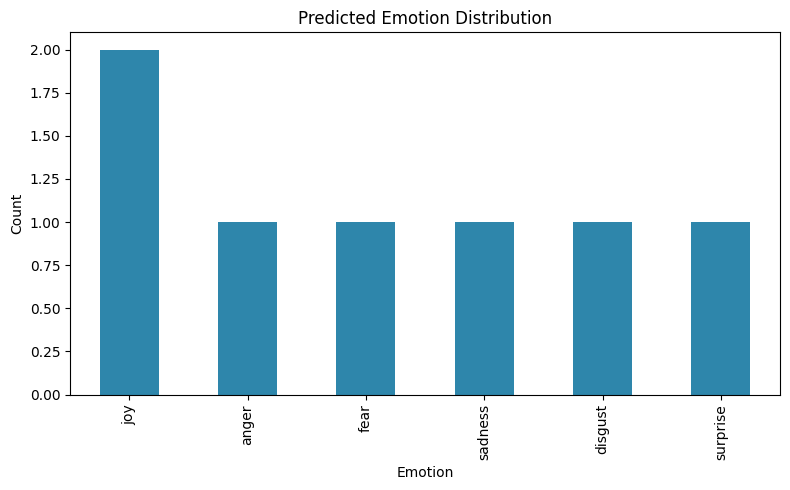

In [46]:
# Plot 1: Predicted emotion distribution (separate cell, no subplot)
plt.figure(figsize=(8, 5))
eval_df["emotion"].value_counts().plot(kind="bar", color="#2E86AB")
plt.title("Predicted Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

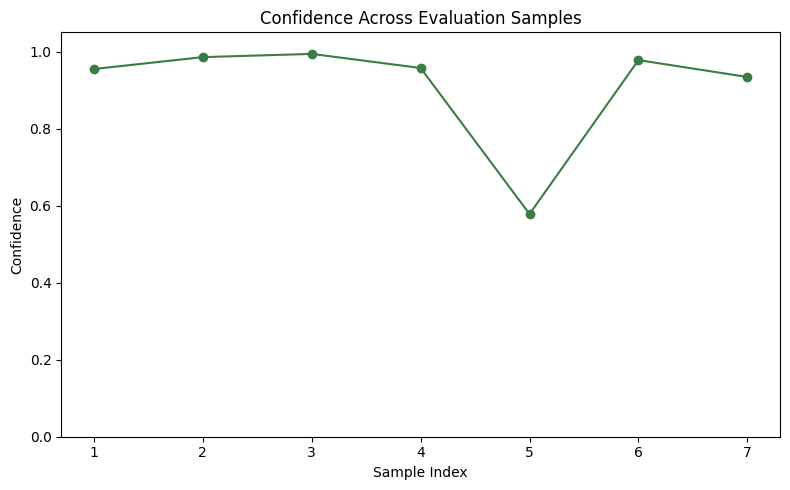

In [47]:
# Plot 2: Confidence across evaluation samples (separate cell, no subplot)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(eval_df) + 1), eval_df["confidence"], marker="o", color="#3A7D44")
plt.title("Confidence Across Evaluation Samples")
plt.xlabel("Sample Index")
plt.ylabel("Confidence")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

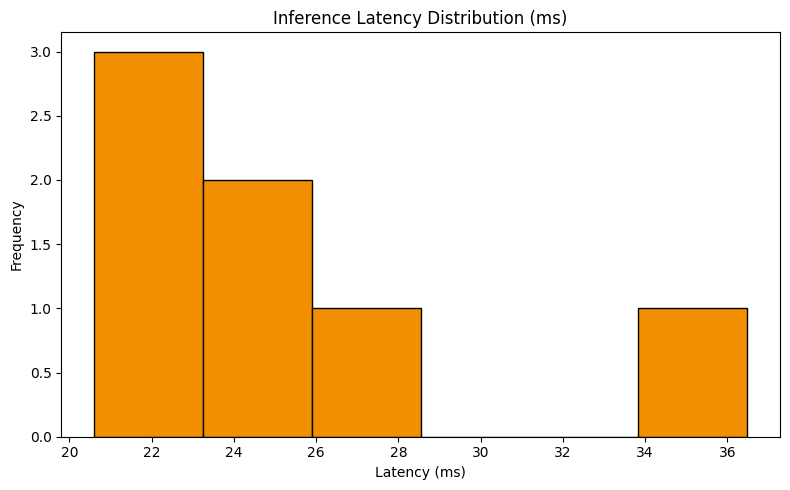

In [48]:
# Plot 3: Inference latency distribution (separate cell, no subplot)
plt.figure(figsize=(8, 5))
plt.hist(eval_df["latency_ms"], bins=6, color="#F18F01", edgecolor="black")
plt.title("Inference Latency Distribution (ms)")
plt.xlabel("Latency (ms)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

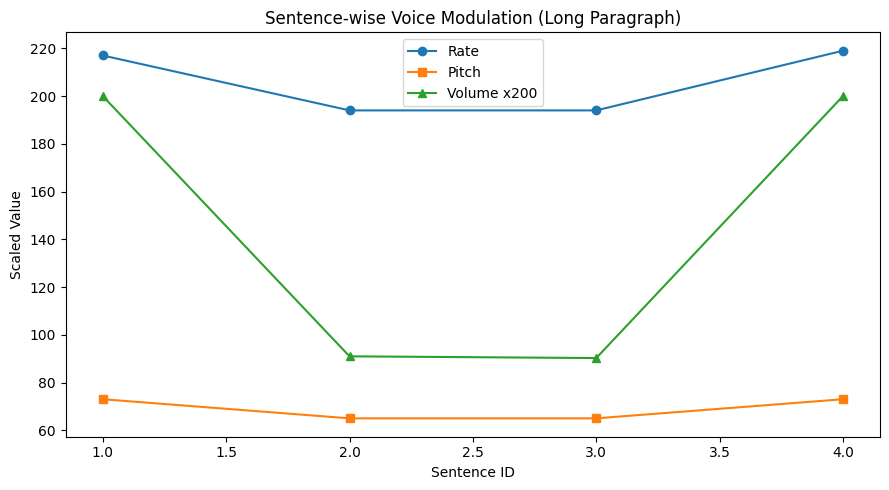

In [49]:
# Plot 4: Sentence-wise voice modulation for long paragraph (separate cell, no subplot)
if 'sentence_df' in globals() and len(sentence_df) > 0:
    plt.figure(figsize=(9, 5))
    x = sentence_df["sentence_id"]
    plt.plot(x, sentence_df["rate"], marker="o", label="Rate")
    plt.plot(x, sentence_df["pitch"], marker="s", label="Pitch")
    plt.plot(x, sentence_df["volume"] * 200, marker="^", label="Volume x200")
    plt.title("Sentence-wise Voice Modulation (Long Paragraph)")
    plt.xlabel("Sentence ID")
    plt.ylabel("Scaled Value")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Run the long paragraph cell first to generate sentence_df.")